<a href="https://colab.research.google.com/github/snehasouravp-cloud/Northstar_analytics/blob/main/Sql_in_R_and_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Loading libraries for data manipulation and SQL queries
# Using sqldf for relational joins and hrbrthemes for the UI/styling
install.packages(c("sqldf", "tidyverse", "lubridate", "hrbrthemes", "viridis"))
library(sqldf)
library(tidyverse)
library(lubridate)
library(hrbrthemes) # For professional-grade reporting themes
library(viridis)

# Fetching raw datasets from the NorthStar repository
# Batch loading CSVs into the environment
repo <- "https://raw.githubusercontent.com/snehasouravp-cloud/Northstar_analytics/refs/heads/main/"

# Automated loading of the relational environment
orders     <- read_csv(paste0(repo, "orders.csv"), show_col_types = FALSE)
deliveries <- read_csv(paste0(repo, "deliveries.csv"), show_col_types= FALSE)
complaints <- read_csv(paste0(repo, "complaints.csv"), show_col_types= FALSE)
hubs       <- read_csv(paste0(repo, "hubs.csv"), show_col_types= FALSE)
drivers    <- read_csv(paste0(repo, "drivers.csv"), show_col_types= FALSE)
incidents  <- read_csv(paste0(repo, "incidents.csv"), show_col_types= FALSE)
customers  <- read_csv(paste0(repo, "customers.csv"), show_col_types= FALSE)
vehicles   <- read_csv(paste0(repo, "vehicles.csv"), show_col_types= FALSE)

cat("Analytical environment synchronized. Ready for diagnostic SQL execution.")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Analytical environment synchronized. Ready for diagnostic SQL execution.

In [ ]:
# SQL to identify if premium service windows are being missed
query_vulnerability <- sqldf("
  SELECT
    o.service_type,
    COUNT(o.order_id) AS total_orders,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failures,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_delivery_cost,
    ROUND(SUM(CASE WHEN d.delivery_status != 'OnTime' THEN 1 ELSE 0 END) * 100.0 / COUNT(o.order_id), 2) AS exception_rate_pct
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type
  ORDER BY exception_rate_pct DESC
")
print(query_vulnerability)

  service_type total_orders failures avg_delivery_cost exception_rate_pct
1     Business          126       25             13.14              42.06
2      Medical          108       16             12.77              35.19
3       Retail          224       28             12.97              34.82
4    Passenger          262       38             12.40              34.73
5       Parcel          230       25             13.08              32.17


In [ ]:
# SQL to link hub infrastructure health to driver behavior
query_hub_friction <- sqldf("
  SELECT
    h.hub_name,
    h.capacity_score,
    COUNT(d.delivery_id) AS volume,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_manual_overrides,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
  FROM hubs h
  JOIN deliveries d ON h.hub_id = d.hub_id
  GROUP BY h.hub_name, h.capacity_score
  HAVING volume > 30
  ORDER BY capacity_score DESC
")
print(query_hub_friction)

        hub_name capacity_score volume avg_manual_overrides avg_rating
1   Central Core             88    115                 0.95       3.67
2 North Exchange             82    136                 1.03       3.84
3     South Link             78    106                 0.92       3.95
4      East Dock             74    119                 0.89       3.90
5    Airport Hub             71    104                 0.91       3.88
6      West Gate             69    127                 0.87       3.92
7  Riverside Hub             66    115                 1.05       3.88
8  Midtown Relay             63    128                 1.11       3.88


In [ ]:
# SQL to correlate employment structure with safety and reliability
query_workforce_risk <- sqldf("
  SELECT
    dr.employment_type,
    COUNT(i.incident_id) AS total_incidents,
    SUM(CASE WHEN i.severity IN ('High', 'Critical') THEN 1 ELSE 0 END) AS severe_incidents,
    ROUND(AVG(dr.training_score), 2) AS avg_training
  FROM drivers dr
  JOIN deliveries d ON dr.driver_id = d.driver_id
  JOIN incidents i ON d.delivery_id = i.delivery_id
  GROUP BY dr.employment_type
")
print(query_workforce_risk)

  employment_type total_incidents severe_incidents avg_training
1        Contract              50               15        76.70
2        FullTime             157               48        74.91
3        PartTime              73               32        73.19


In [ ]:
# SQL to identify high-value revenue at risk from open complaints
query_revenue_risk <- sqldf("
  SELECT
    o.service_type,
    SUM(o.order_value) AS revenue_at_risk,
    COUNT(c.complaint_id) AS open_complaints,
    ROUND(AVG(c.compensation_amount), 2) AS avg_payout
  FROM orders o
  JOIN complaints c ON o.order_id = c.order_id
  WHERE c.status = 'Open'
  GROUP BY o.service_type
  ORDER BY revenue_at_risk DESC
")
print(query_revenue_risk)

  service_type revenue_at_risk open_complaints avg_payout
1    Passenger         1529.89              18      20.21
2       Retail         1136.16              12      13.70
3     Business         1048.03               7      18.62
4      Medical          879.15              11      23.91
5       Parcel          670.05               8      17.48


In [ ]:
# SQL to determine if aging battery health is driving up charging costs
query_asset_decay <- sqldf("
  SELECT
    v.vehicle_type,
    CASE WHEN v.battery_health_pct < 75 THEN 'At Risk' ELSE 'Healthy' END AS status,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_trip_cost,
    COUNT(d.delivery_id) AS total_trips
  FROM vehicles v
  JOIN deliveries d ON v.vehicle_id = d.vehicle_id
  GROUP BY v.vehicle_type, status
")
print(query_asset_decay)

  vehicle_type  status avg_trip_cost total_trips
1     CargoVan At Risk         12.88         123
2     CargoVan Healthy         12.80         100
3       Diesel At Risk         12.89          78
4       Diesel Healthy         12.80          66
5           EV At Risk         13.23          94
6           EV Healthy         12.81         245
7       Hybrid At Risk         12.35          91
8       Hybrid Healthy         12.93         153


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”


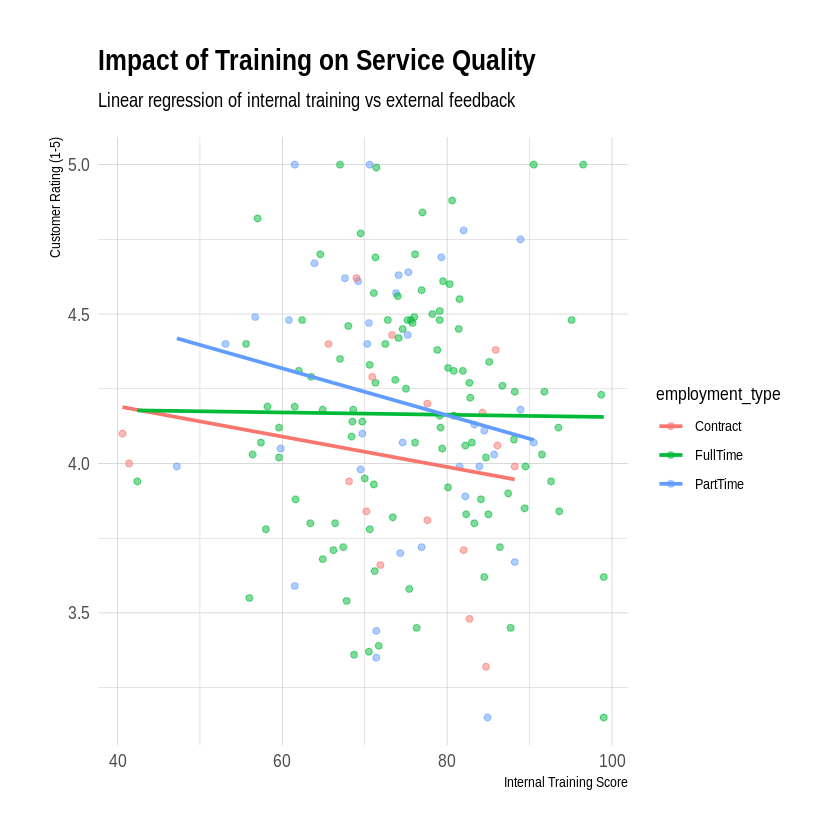

In [ ]:
ggplot(drivers, aes(x = training_score, y = driver_rating, color = employment_type)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", se = FALSE) +
  theme_ipsum() +
  labs(title = "Impact of Training on Service Quality",
       subtitle = "Linear regression of internal training vs external feedback",
       x = "Internal Training Score", y = "Customer Rating (1-5)")

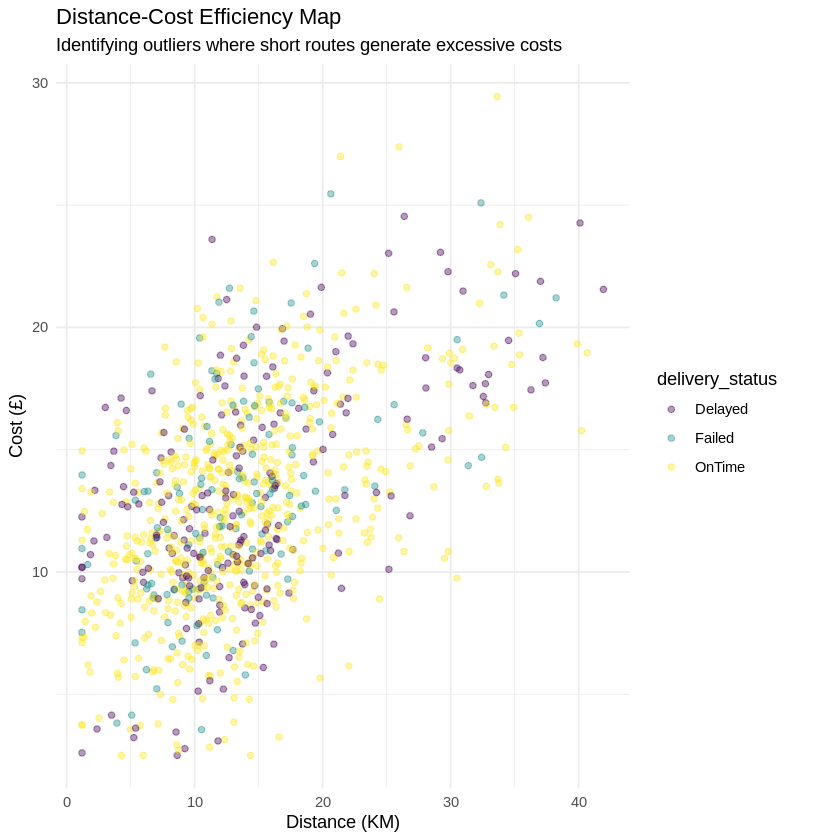

In [ ]:
ggplot(deliveries, aes(x = route_distance_km, y = fuel_or_charge_cost, color = delivery_status)) +
  geom_jitter(alpha = 0.4) +
  scale_color_viridis_d() +
  theme_minimal() +
  labs(title = "Distance-Cost Efficiency Map",
       subtitle = "Identifying outliers where short routes generate excessive costs",
       x = "Distance (KM)", y = "Cost (£)")

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


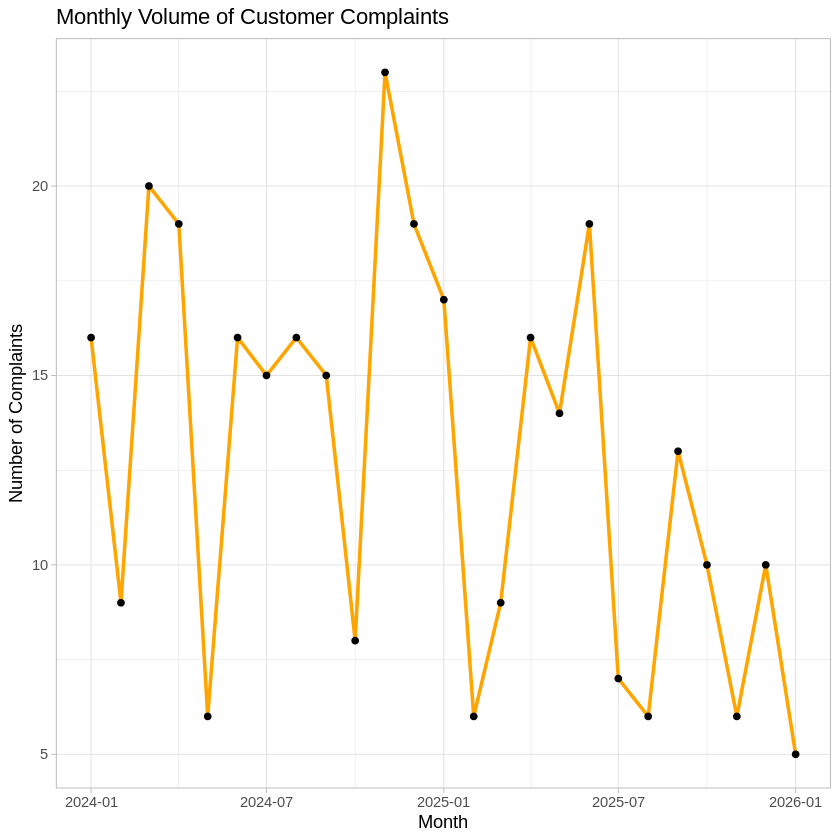

In [ ]:
complaints %>%
  mutate(month = floor_date(ymd_hms(created_at), "month")) %>%
  group_by(month) %>%
  summarise(count = n()) %>%
  ggplot(aes(x = month, y = count)) +
  geom_line(color = "orange", size = 1) +
  geom_point() +
  labs(title = "Monthly Volume of Customer Complaints",
       x = "Month", y = "Number of Complaints") +
  theme_light()

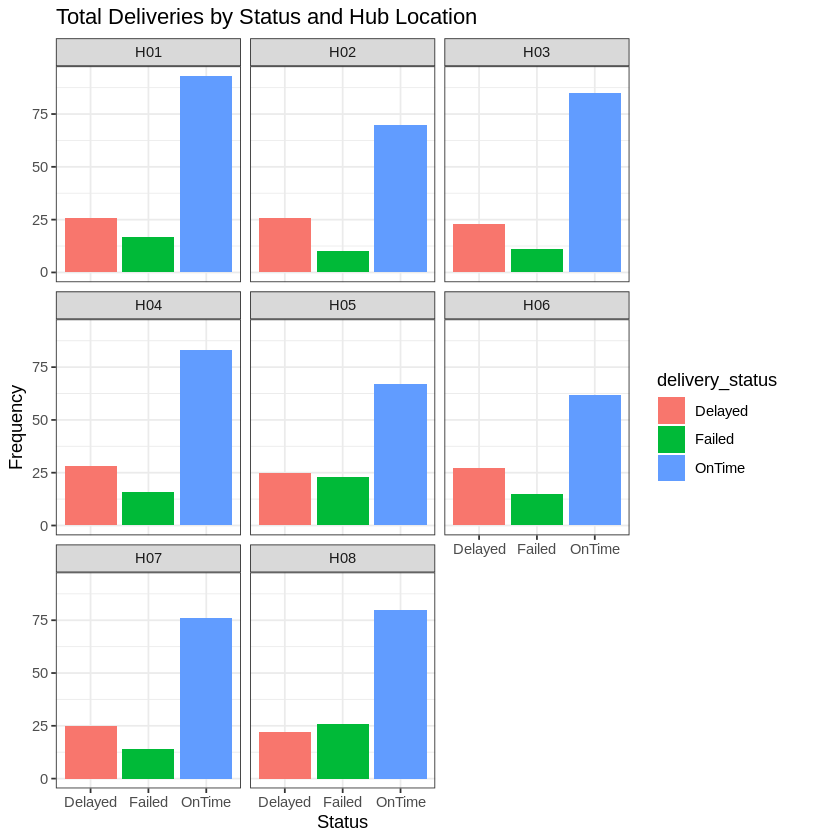

In [ ]:
ggplot(deliveries, aes(x = delivery_status, fill = delivery_status)) +
  geom_bar() +
  facet_wrap(~hub_id) +
  labs(title = "Total Deliveries by Status and Hub Location",
       x = "Status", y = "Frequency") +
  theme_bw()

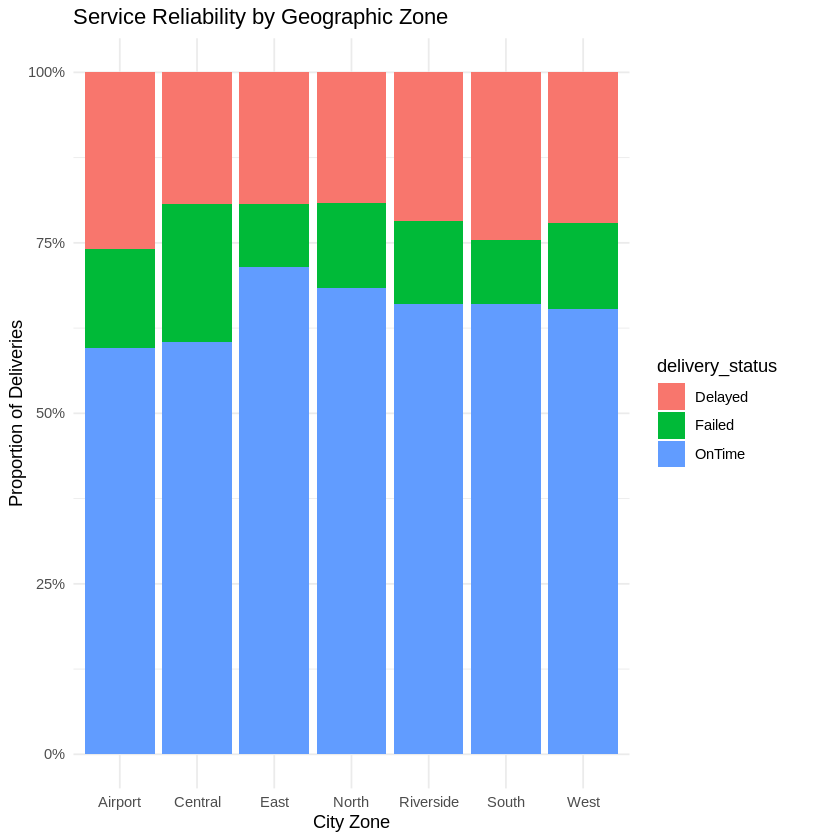

In [ ]:
deliveries %>%
  left_join(hubs, by = "hub_id") %>%
  ggplot(aes(x = zone, fill = delivery_status)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal() +
  labs(title = "Service Reliability by Geographic Zone",
       x = "City Zone", y = "Proportion of Deliveries")